# Vechta - Mapping

In [3]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [5]:
client = bigquery.Client(project='subugoe-collaborative')

In [6]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Vechta' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/045y6d111' -- 'Universität Vechta'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [7]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4220718021
1,not assigned,Universität Vechta,"University of Vechta, Vechta, Germany",https://openalex.org/W4283398054
2,not assigned,Universität Vechta,"Fach Sportwissenschaft, Universität Vechta, Dr...",https://openalex.org/W4283767294
3,not assigned,Universität Vechta,"University of Vechta, Vechta, Germany",https://openalex.org/W4283828092
4,not assigned,Universität Vechta,"University of Vechta, Business and Ethics, Fac...",https://openalex.org/W4281617522


In [128]:
MAPPING_DICT = {
    #'Bildung, Erziehung, Gesellschaft: Vechta-Institut für Inklusion': [],
    'Fakultät I': ['department of education', 'erziehungswissenschaften', 'gerontolog(ie|y)', 'soziale arbeit', 'education and social',
                   'psychology', '(faculty|department) (?<!i)i,', '(?<!natural and\s)(educational|soci(a|eta)l) science', 'social work', 'gesellschaftswissenschaften', 'ethics',
                   'economics and sustainability', 'pedagogy', 'inclusion', 'sociology'
                  ],
    'Fakultät II': ['germanisti(k|sch)', 'geography', 'geo(-|\s)lab', 'biology', '(faculty|department) ii', 'sport',
                    'english', 'schulpädagogik', 'cultural (sciences|studies)', 'landschaftsökologie', 'landscape ecology',
                    'kulturwissenschaften', 'natur- und sozialwissenschaften', 'agriculture', 'media research', 'geschichte', 
                    'history', 'faculty of natural'
                   ],
    'Vechta Institute of Sustainability Transformation in Rural Areas': ['rural areas', 'sustainability transformation'],
    'Zentrum für Lehrer*innenbildung': ['teacher training']
}

In [129]:
with open('./mapping_tables_fak/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [130]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [131]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [132]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Universität Vechta,"University of Vechta, Germany",https://openalex.org/W4220718021
1,None,Universität Vechta,"University of Vechta, Vechta, Germany",https://openalex.org/W4283398054
2,Fakultät II,Universität Vechta,"Fach Sportwissenschaft, Universität Vechta, Dr...",https://openalex.org/W4283767294
3,None,Universität Vechta,"University of Vechta, Vechta, Germany",https://openalex.org/W4283828092
4,Fakultät I,Universität Vechta,"University of Vechta, Business and Ethics, Fac...",https://openalex.org/W4281617522
...,...,...,...,...
498,Fakultät II,Universität Vechta,"Department of Sport Science, University of Vec...",https://openalex.org/W4413720067
499,None,Universität Vechta,University of Vechta,https://openalex.org/W4413720067
500,None,Universität Vechta,"Universität Vechta , ,",https://openalex.org/W4406022562
501,Fakultät I,Universität Vechta,"Institute of Gerontology, Faculty I, Vechta Un...",https://openalex.org/W4407189019


In [133]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Vechta, Germany',
       'University of Vechta, Vechta, Germany', 'University of Vechta',
       'University of Vechta , Vechta , Germany',
       'University of Vechta , Vechta , Germany , TU Dresden , Dresden , Germany , Leipzig University , Leipzig , Germany',
       'University of Vechta , Vechta ,', 'Universität Vechta',
       'University of Vechta, Driverstraße 22, 49377, Vechta, Germany',
       'U. of Vechta', 'Universität Vechta  Driverstr. 22 49377 Vechta',
       'University Vechta', 'University of Vechta Vechta, Germany',
       'University of Vechta Vechta Germany',
       'Unversity of Vechta , Vechta, Niedersachsen , Germany',
       'Universität , Vechta Germany',
       'Universität Vechta Vechta Deutschland',
       'University of Vechta, 49377, Vechta, Germany',
       'University of Vechta, 49377 Vechta, Germany',
       'Universität Vechta, Vechta, Deutschland',
       'University of Vechta  Vechta Germany',
       'University of Vechta, Driv

In [134]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät I,129
1,Fakultät II,136
2,Vechta Institute of Sustainability Transformat...,12
3,Zentrum für Lehrer*innenbildung,1
4,NaN,225


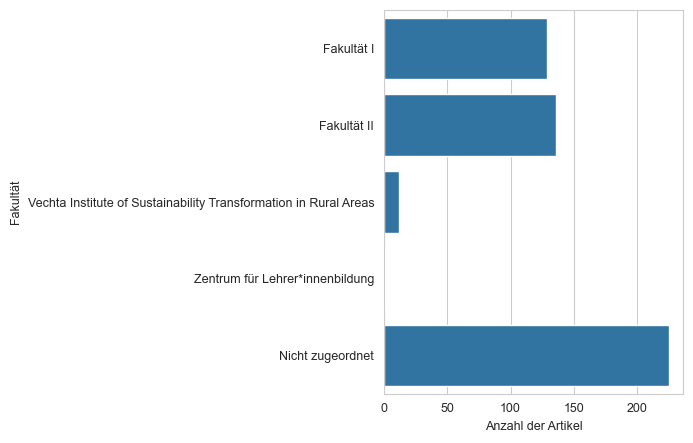

In [135]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [136]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.5526838966202783

In [267]:
MAPPING_DICT_DEPT = {
    'Fakultät I': {
        'Fach Erziehungswissenschaften': ['erziehungswissenschaften', 'educational sciences', 'department of education', 'primary school'],
        'Fach Gerontologie': ['gerontolog(ie|y)'],
        'Fach Management sozialer Dienstleistungen': ['sozialer dienstleistungen', 'business (and )?ethics'],
        'Fach Soziale Arbeit': ['soziale arbeit', 'social work'],
        'Fach Soziologie': ['soziolog(ie|y)'],
        'Fach Sustainability, Entrepreneurship and Innovation': ['entrepreneurship', 'sustainability'],
        'Lehr- und Forschungseinheit Pädagogische Psychologie': ['psycholog(ie|y)'],
    },
    'Fakultät II': {
        'Fach Anglistik': ['anglistik', 'english linguistics', 'department of english', 'english department'],
        'Fach Biologie': ['biolog(ie|y)'],
        'Fach Designpädagogik': ['designpädagogik'],
        'Fach Geographie': ['geograph(ie|y)', 'landscape', 'geo-lab', 'landschaftsökologie', 'agriculture'],
        'Fach Germanistik': ['germanisti(k|sch)'],
        'Fach Geschichtswissenschaft': ['geschichtswissenschaft', 'history', 'geschichte'],
        'Fach Katholische Theologie': ['katholische theologie'],
        'Fach Kulturwissenschaften': ['kulturwissenschaften', 'cultural (studies|sciences)', 'media research'],
        'Fach Mathematik': ['mathematik'],
        'Fach Musik': ['musi(k|c)'],
        'Fach Philosophie': ['philosoph(ie|y)'],
        'Fach Politikwissenschaft': ['politikwissenschaft'],
        'Fach Sachunterricht': ['sachunterricht', 'didaktik'],
        'Fach Sportwissenschaft': ['sport(s)?(\s)?science', 'sportwissenschaft'],
    }
}

In [268]:
with open('./mapping_tables_dept/vechta.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [269]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [270]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät II']['raw_affiliation_string'].apply(map_dept, 
                                                                        faculty='Fakultät II')

In [271]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät II') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Faculty of Natural and Social Sciences, University of Vechta, Driverstraße 22, D-49377 Vechta, Germany',
       'Faculty II, University of Vechta, Vechta, Germany',
       'Faculty of Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'University of Vechta, Faculty II',
       'Faculty II, Professorship (W1) of Bioeconomy and Resource Efficiency, Vechta Institute of Sustainability Transformations in Rural Areas, University of Vechta, Driverstraße 22, Vechta D-49377, Germany',
       'Department II - Natural and Social Sciences, University of Vechta, Vechta, Germany',
       'Geo Laboratory, University of Vechta, Vechta, Germany',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Kreuzweg 3–5, 49377, Vechta, Deutschland',
       'Fakultät Natur- und Sozialwissenschaften, Universität Vechta, Vechta, Deutschland',
       'Faculty II, University of Vechta, Driverstr. 22, D-49377, Vechta, Germany'],
      dtype=object)

In [272]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Fach Anglistik,4
1,Fach Biologie,7
2,Fach Geographie,64
3,Fach Germanistik,13
4,Fach Geschichtswissenschaft,3
5,Fach Kulturwissenschaften,10
6,Fach Sachunterricht,2
7,Fach Sportwissenschaft,18
8,NaN,15


In [273]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät II']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,Fakultät II,Universität Vechta,"Fach Sportwissenschaft, Universität Vechta, Dr...",https://openalex.org/W4283767294,Fach Sportwissenschaft
16,Fakultät II,Universität Vechta,"Institute for Applied Physical Geography, Univ...",https://openalex.org/W4283386257,Fach Geographie
18,Fakultät II,Universität Vechta,"Department of Sports Science, University of Ve...",https://openalex.org/W4205604287,Fach Sportwissenschaft
19,Fakultät II,Universität Vechta,"Geography—Faculty II, University of Vechta, Dr...",https://openalex.org/W4224000114,Fach Geographie
20,Fakultät II,Universität Vechta,"Landscape Ecology, University of Vechta",https://openalex.org/W4221034691,Fach Geographie
...,...,...,...,...,...
483,Fakultät II,Universität Vechta,"Department of Geography, University of Vechta,...",https://openalex.org/W4405500281,Fach Geographie
490,Fakultät II,Universität Vechta,"English Linguistics , University of Vechta , V...",https://openalex.org/W4407195635,Fach Anglistik
492,Fakultät II,Universität Vechta,"Chair of Landscape Ecology, University of Vech...",https://openalex.org/W3194317304,Fach Geographie
493,Fakultät II,Universität Vechta,"Landscape Ecology, University of Vechta, P.O. ...",https://openalex.org/W3208821015,Fach Geographie
